<a href="https://www.kaggle.com/code/amirmansour/loan-approval-classification?scriptVersionId=351964085" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv


# 🏦 Loan Approval Classification Project

**Objective:**
Develop a Machine Learning classification model to predict whether a loan application should be **approved or rejected**, helping banking employees make data-driven decisions.

**Dataset:**
[Loan Approval Classification Dataset – Kaggle](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data)

**Problem Type:** Binary Classification

**Target Variable:** `loan_status`

* `1` → Approved
* `0` → Rejected

**Performance Target:**
Achieve a **minimum test accuracy of 92%**, while also evaluating Precision, Recall, F1-Score, and ROC-AUC.

**Goal:**
Build a reliable classification model that performs well on **unseen data** and can serve as a decision-support tool for loan assessment.


## Import libraries

In [2]:
import pandas as pd 
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay , accuracy_score , classification_report

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import  XGBClassifier

## Import Dataset

In [3]:
 # Load the dataset
df = pd.read_csv('/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv')
df.sample(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
40855,22.0,male,Associate,64564.0,0,MORTGAGE,8000.0,EDUCATION,16.11,0.12,4.0,615,No,0
37845,33.0,female,Master,192888.0,13,MORTGAGE,10000.0,HOMEIMPROVEMENT,12.35,0.05,12.0,656,Yes,0
38906,30.0,male,Master,47044.0,4,MORTGAGE,2454.0,HOMEIMPROVEMENT,11.16,0.05,6.0,618,Yes,0
33341,34.0,female,Associate,29524.0,9,RENT,6215.0,EDUCATION,10.04,0.21,14.0,649,No,0
2270,24.0,female,Associate,48616.0,0,RENT,13000.0,DEBTCONSOLIDATION,14.26,0.27,3.0,565,No,1
34780,28.0,female,Master,48966.0,2,RENT,1400.0,EDUCATION,9.20,0.03,7.0,684,Yes,0
20849,34.0,female,Doctorate,67444.0,9,RENT,9000.0,VENTURE,7.74,0.13,6.0,659,Yes,0
43944,32.0,male,Bachelor,91497.0,6,MORTGAGE,19672.0,HOMEIMPROVEMENT,13.38,0.21,8.0,582,No,1
25624,27.0,female,Master,106464.0,8,MORTGAGE,20000.0,DEBTCONSOLIDATION,12.84,0.19,10.0,720,No,0
35865,26.0,female,High School,108942.0,7,MORTGAGE,11054.0,PERSONAL,10.53,0.10,4.0,628,No,0


##  Check data quality

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
df[df.duplicated()]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [7]:
df.describe(include='O').T

,count,unique,top,freq
person_gender,45000,2,male,24841
person_education,45000,5,Bachelor,13399
person_home_ownership,45000,4,RENT,23443
loan_intent,45000,6,EDUCATION,9153
previous_loan_defaults_on_file,45000,2,Yes,22858


## Split the data 

In [8]:
Features = [x for x in df.columns if x != 'loan_status']
X = df[Features]
y = df['loan_status'] 

In [9]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)

## Feature Preprocessing Configuration

To prepare the dataset for machine learning, features are grouped according to their data type and preprocessing requirements. Categorical variables are encoded using **Ordinal Encoding** or **One-Hot Encoding**, while numerical features are standardized using **StandardScaler**.

Two preprocessing configurations are defined: one for categorical features only and another complete preprocessor combining categorical encoding with numerical standardization.


In [10]:
# Features for ordinal encoding
Ordinal_features = ["person_gender","previous_loan_defaults_on_file"]

# Features for One-Hot Encoding
onehot_features = ["person_home_ownership","person_education","loan_intent"]

# Numerical features 
numeric_features = ["person_age","person_income","person_emp_exp","loan_amnt","loan_int_rate","loan_percent_income",
                    "cb_person_cred_hist_length","credit_score"]

# Categorical Features    
categorical_features  = ["person_gender","previous_loan_defaults_on_file", "person_home_ownership",
                         "person_education","loan_intent"]

preprocessor = ColumnTransformer(
    transformers = [
        ("Ordinal" , OrdinalEncoder() , Ordinal_features),
        ("onehot" , OneHotEncoder() , onehot_features),
        ("standraizaton" , StandardScaler() , numeric_features)
    ]
)

## Classification Model Selection

A diverse set of classification algorithms is defined to evaluate different modeling approaches for the loan approval problem. The models include linear, distance-based, probabilistic, tree-based, and gradient-boosting methods, providing a broad baseline for performance comparison before hyperparameter optimization.


In [11]:
Models = {
    "Logistic_Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "SVM" : SVC(),
    "Naive_Bayes" : GaussianNB(),
    "Decision_Tree" : DecisionTreeClassifier(),
    "Random_Forest" : RandomForestClassifier(),
    "XGboost" : XGBClassifier(),
    "LightGBM" : LGBMClassifier(),
}

## Initial Model Benchmarking

Multiple classification algorithms are trained using the same preprocessing pipeline to establish a baseline comparison. Each model is evaluated on training and test data using accuracy, classification reports, and confusion matrices to identify promising candidates for further hyperparameter tuning.


Classification Report for Logistic_Regression:

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      8730
           1       0.77      0.75      0.76      2520

    accuracy                           0.89     11250
   macro avg       0.85      0.84      0.84     11250
weighted avg       0.89      0.89      0.89     11250



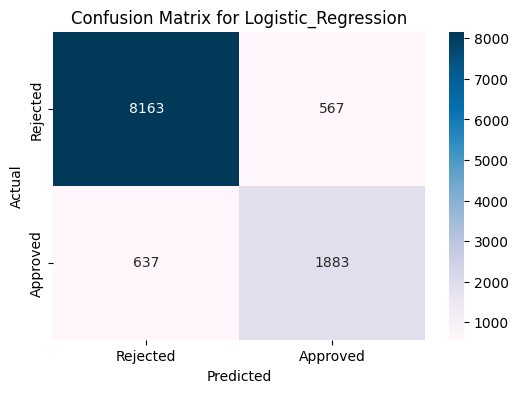



Classification Report for KNN:

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      8730
           1       0.81      0.68      0.74      2520

    accuracy                           0.89     11250
   macro avg       0.86      0.81      0.83     11250
weighted avg       0.89      0.89      0.89     11250



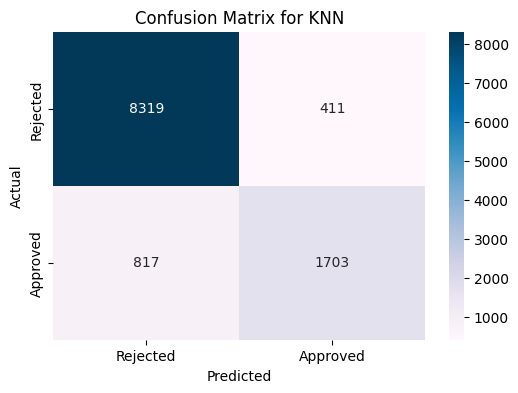



Classification Report for SVM:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95      8730
           1       0.85      0.76      0.80      2520

    accuracy                           0.92     11250
   macro avg       0.89      0.86      0.87     11250
weighted avg       0.91      0.92      0.91     11250



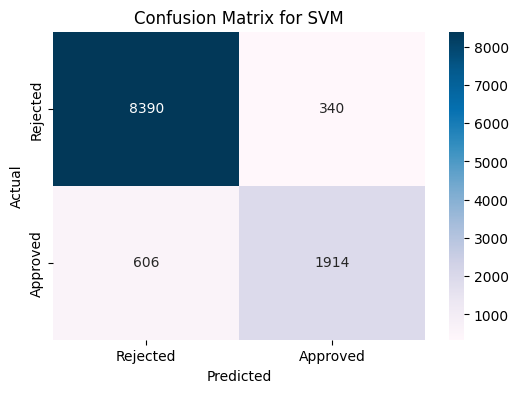



Classification Report for Naive_Bayes:

              precision    recall  f1-score   support

           0       0.99      0.68      0.81      8730
           1       0.47      0.97      0.64      2520

    accuracy                           0.75     11250
   macro avg       0.73      0.83      0.72     11250
weighted avg       0.87      0.75      0.77     11250



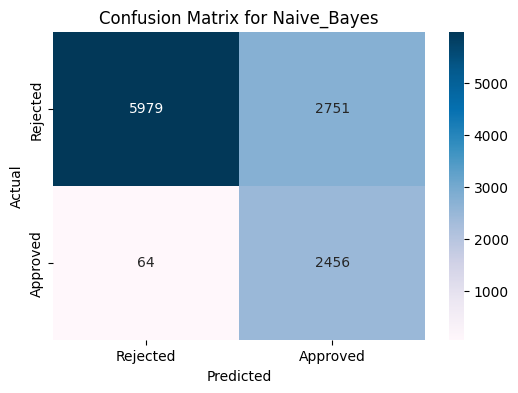



Classification Report for Decision_Tree:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      8730
           1       0.75      0.78      0.77      2520

    accuracy                           0.89     11250
   macro avg       0.84      0.85      0.85     11250
weighted avg       0.89      0.89      0.89     11250



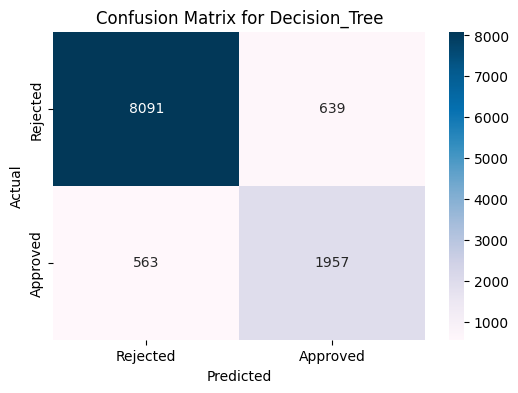



Classification Report for Random_Forest:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      8730
           1       0.89      0.77      0.83      2520

    accuracy                           0.93     11250
   macro avg       0.91      0.87      0.89     11250
weighted avg       0.93      0.93      0.93     11250



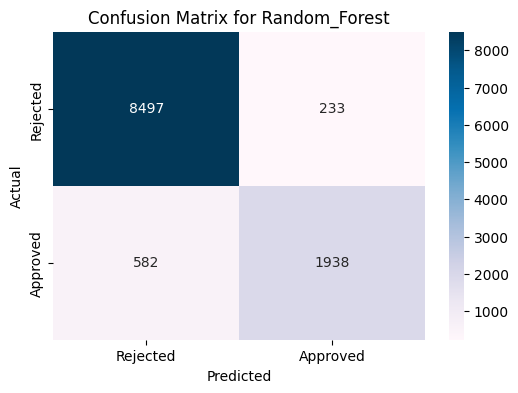



Classification Report for XGboost:

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      8730
           1       0.88      0.80      0.84      2520

    accuracy                           0.93     11250
   macro avg       0.91      0.89      0.90     11250
weighted avg       0.93      0.93      0.93     11250



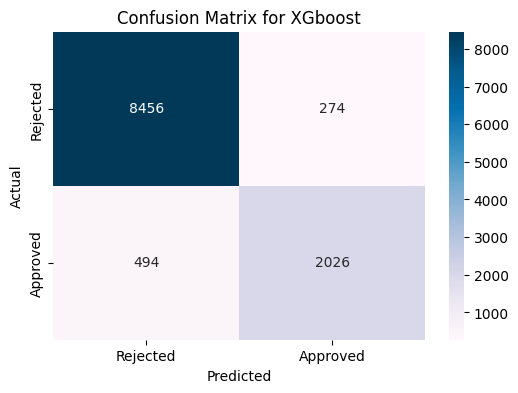



[LightGBM] [Info] Number of positive: 7480, number of negative: 26270
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1217
[LightGBM] [Info] Number of data points in the train set: 33750, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221630 -> initscore=-1.256195
[LightGBM] [Info] Start training from score -1.256195


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      8730
           1       0.88      0.79      0.83      2520

    accuracy                           0.93     11250
   macro avg       0.91      0.88      0.89     11250
weighted avg       0.93      0.93      0.93     11250



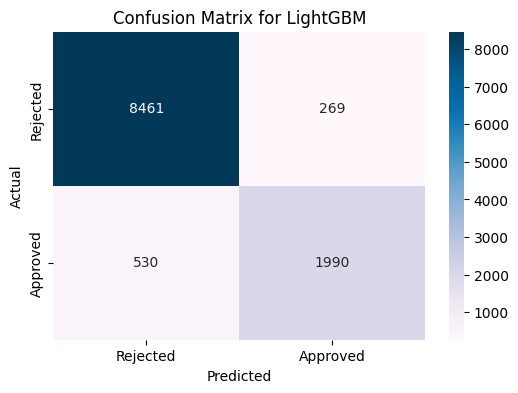



Model Performance Table:


,Model,Train Score,Test Score,Accuracy
0,Logistic_Regression,0.897926,0.892978,0.892978
1,KNN,0.927111,0.890844,0.890844
2,SVM,0.924119,0.915911,0.915911
3,Naive_Bayes,0.749304,0.749778,0.749778
4,Decision_Tree,1.000000,0.893156,0.893156
5,Random_Forest,1.000000,0.927556,0.927556
6,XGboost,0.969126,0.931733,0.931733
7,LightGBM,0.948859,0.928978,0.928978


In [12]:
# Making For loop to Try all the model once and evaluate 

# List to save all the Accuracies
results = []

for name,model in  Models.items() : 
        
        # The pipeline for the models 
        pipeline = Pipeline(
        steps= [("preprocessor",preprocessor),
                ("Model" , model)]
    )
        # Fit the Model
        pipeline.fit(X_train,y_train)

        
        # Predictions on validation set
        y_pred = pipeline.predict(X_test)


        # Train and Test Score
        train_score = pipeline.score(X_train, y_train)
        test_score = pipeline.score(X_test, y_test)


        # Accuracy Score
        Accuracy = accuracy_score(y_test , y_pred)

        results.append({
            'Model' : name , 
            'Train Score' : train_score,
            'Test Score' : test_score,
            'Accuracy' : Accuracy
        })
        

        # Classification report
        print(f"Classification Report for {name}:\n")
        print(classification_report(y_test , y_pred))
        
        # Confusion Matrix
        cm = confusion_matrix(y_test , y_pred)
        
        # Plotting confusion matrix
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
        plt.title(f'Confusion Matrix for {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
        
        print("\n" + "="*60 + "\n")

results_df = pd.DataFrame(results)

# Display the model performance table
print("Model Performance Table:")
display(results_df)
            

## Best Performing Model Selection

The best-performing classification model is identified by comparing the accuracy scores of all evaluated algorithms. The model with the highest test accuracy is selected as the leading candidate for subsequent hyperparameter tuning and final evaluation.


In [13]:
# Identify the best model by accuracy
best_model_row = results_df.loc[results_df['Accuracy'].idxmax()]
best_model_name = best_model_row['Model']
best_model_accuracy = best_model_row['Accuracy']

print(f"\nBest Model: {best_model_name} with Accuracy: {best_model_accuracy:.4%}")


Best Model: XGboost with Accuracy: 93.1733%


## CatBoost Model Evaluation Without Manual Categorical Encoding

CatBoost is evaluated using the original categorical features without applying manual categorical encoding. The model internally handles categorical variables through its native categorical feature processing, allowing us to compare its performance against models trained using the preprocessing pipeline.

In [14]:
# Initialize the CatBoost classifier
catboost_model = CatBoostClassifier()

# Train the model using native categorical feature handling
catboost_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

Learning rate set to 0.046292
0:	learn: 0.5863428	total: 85.6ms	remaining: 1m 25s
1:	learn: 0.5090072	total: 113ms	remaining: 56.1s
2:	learn: 0.4461993	total: 136ms	remaining: 45.2s
3:	learn: 0.3979976	total: 160ms	remaining: 39.8s
4:	learn: 0.3597238	total: 183ms	remaining: 36.5s
5:	learn: 0.3317301	total: 208ms	remaining: 34.4s
6:	learn: 0.3101711	total: 233ms	remaining: 33.1s
7:	learn: 0.2943102	total: 258ms	remaining: 31.9s
8:	learn: 0.2799421	total: 281ms	remaining: 31s
9:	learn: 0.2672972	total: 305ms	remaining: 30.2s
10:	learn: 0.2590473	total: 329ms	remaining: 29.5s
11:	learn: 0.2515225	total: 354ms	remaining: 29.1s
12:	learn: 0.2457369	total: 377ms	remaining: 28.6s
13:	learn: 0.2399572	total: 405ms	remaining: 28.5s
14:	learn: 0.2353277	total: 428ms	remaining: 28.1s
15:	learn: 0.2312023	total: 451ms	remaining: 27.8s
16:	learn: 0.2277605	total: 476ms	remaining: 27.5s
17:	learn: 0.2239684	total: 499ms	remaining: 27.2s
18:	learn: 0.2211664	total: 523ms	remaining: 27s
19:	learn: 0.

CatBoostClassifier()

In [15]:
# Generate predictions
y_pred_catboost = catboost_model.predict(X_test).ravel()

## CatBoost Model Performance Evaluation

The trained CatBoost model is evaluated using the test dataset to measure its classification performance. The evaluation includes **test accuracy, a classification report, and a confusion matrix** to assess overall performance and the model's ability to correctly classify loan approval outcomes.

Classification Report for CatBoost:

              precision    recall  f1-score   support

    Rejected       0.94      0.97      0.96      8730
    Approved       0.89      0.80      0.84      2520

    accuracy                           0.93     11250
   macro avg       0.92      0.89      0.90     11250
weighted avg       0.93      0.93      0.93     11250



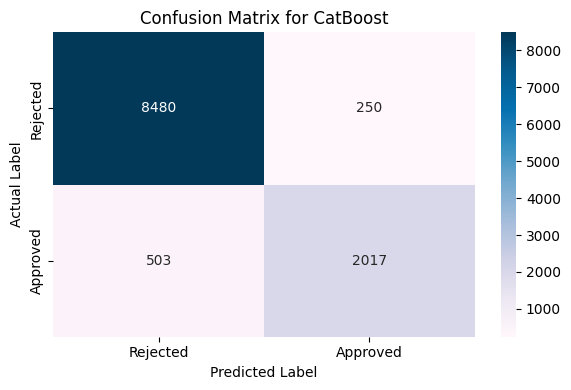


CatBoost Test Accuracy: 93.31%


In [16]:
# Calculate accuracy
catboost_accuracy = accuracy_score(y_test, y_pred_catboost)

# Display classification report
print("Classification Report for CatBoost:\n")
print(classification_report(y_test,y_pred_catboost,target_names=["Rejected", "Approved"]))

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_catboost)

# Plot confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap( cm,annot=True,fmt="d",cmap="PuBu",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix for CatBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Display accuracy
print(f"\nCatBoost Test Accuracy: {catboost_accuracy:.2%}")

## CatBoost Hyperparameter Optimization

RandomizedSearchCV is used to identify the optimal CatBoost hyperparameter combination based on cross-validated accuracy. Stratified 5-fold cross-validation is applied to preserve the class distribution across folds, while the best-performing configuration is automatically refitted using the training data.

In [17]:
# Initialize the CatBoost classifier with the main training and evaluation settings.
model = CatBoostClassifier(
loss_function="Logloss",
    eval_metric="Accuracy",
    iterations=1000,
    verbose=0,
    random_seed=42,
    thread_count=1,
    random_strength = 0
)
# Define the hyperparameter search space to find the best CatBoost configuration.
param_distribution = {
    "depth": [6, 8 , 9],
    "learning_rate": [0.1 , 0.2 , 0.3],
    "l2_leaf_reg": [3,4 ,5 ]
}

# Configure Stratified K-Fold cross-validation while preserving the class distribution.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Configure RandomizedSearchCV to evaluate every hyperparameter combination using cross-validation.
Randomized_Search = RandomizedSearchCV(
    estimator=model,
    param_distributions =param_distribution,
    scoring="accuracy",
    n_iter=10,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)

# Train and evaluate all hyperparameter combinations using the original categorical features.
Randomized_Search.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=CatBoostClassifier(eval_metric='Accuracy', iterations=1000, loss_function='Logloss', random_seed=42, random_strength=0, thread_count=1, verbose=0),
                   n_jobs=-1,
                   param_distributions={'depth': [6, 8, 9],
                                        'l2_leaf_reg': [3, 4, 5],
                                        'learning_rate': [0.1, 0.2, 0.3]},
                   scoring='accuracy', verbose=2)

In [18]:
print("Best Parameters:")
print(Randomized_Search.best_params_)

print("Best CV Accuracy:")
print(Randomized_Search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'l2_leaf_reg': 4, 'depth': 6}
Best CV Accuracy:
0.9336296296296297


## Feature Importance Analysis — Optimized CatBoost Model

The feature importance scores are extracted from the best CatBoost model identified by RandomizedSearchCV. These scores help quantify the contribution of each feature to the model's predictions and provide insights into the factors influencing loan approval classification.

,Feature,Importance
12,previous_loan_defaults_on_file,55.772739
9,loan_percent_income,10.265783
3,person_income,8.813008
8,loan_int_rate,6.653709
5,person_home_ownership,4.867416
7,loan_intent,3.879983
11,credit_score,3.038129
6,loan_amnt,2.614763
0,person_age,1.323906
4,person_emp_exp,1.005076


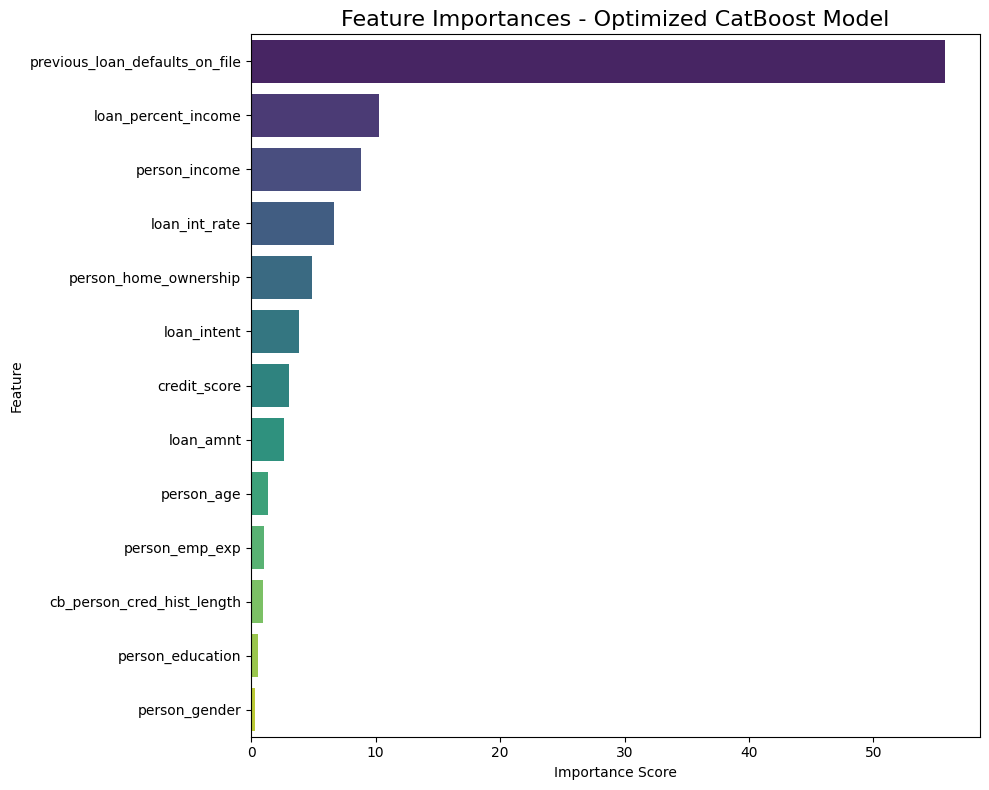

In [19]:
# Retrieve the best CatBoost model identified by RandomizedSearchCV
final_catboost_model = Randomized_Search.best_estimator_

# Extract feature importance scores from the optimized model
feature_importances = final_catboost_model.feature_importances_

# Retrieve the original feature names
feature_names = X_train.columns.tolist()

# Create a DataFrame containing feature names and importance scores
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance table
display(feature_importance_df)

# Select the top 15 most important features for visualization
top_features = feature_importance_df.head(15)

# Plot feature importance scores
plt.figure(figsize=(10, 8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features,
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Feature Importances - Optimized CatBoost Model",
    fontsize=16
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Saving the Final CatBoost Model

The optimized CatBoost model obtained from `RandomizedSearchCV` is saved using CatBoost's native **`.cbm` format**. This format preserves the trained model and its CatBoost-specific configuration, making it suitable for later deployment and integration with the FastAPI backend without requiring retraining.

In [20]:
final_catboost_model.save_model("catboost_loan_approval.cbm")